# 02 - Data Ingestion and Exploratory Data Analysis

In this notebook I inspect the raw data excel file and prepare the dataset for the deterministic baseline and Monte Carlo simulation.

The project uses two operating scenarios:

* Scenario Alpha
* Scenario Bravo

The three systems in the cooling chain are:

* HVAC
* CW
* FW

The main thing I need to be careful with in this stage is the cascade structure. Some upstream loads are already embedded in downstream systems, so I should not blindly add HVAC + CW + FW together.

## Import libraries and set file paths

In [1]:
# Importing the required libraries
from pathlib import Path
import pandas as pd
import numpy as np

# Plotting is useful for the EDA, but the rest of the notebook should still run if these are not installed yet
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plotting_available = True
except ModuleNotFoundError:
    plotting_available = False
    print("matplotlib and seaborn are not installed yet, so the table outputs will run but the graphs will be skipped.")

# Find the project root. This works if the notebook is run from the repo root or from the notebooks folder.
current_path = Path.cwd().resolve()
if (current_path / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path
elif (current_path.parent / "data" / "raw" / "data.xlsx").exists():
    project_root = current_path.parent
else:
    raise FileNotFoundError("Could not find data/raw/data.xlsx. Please open VS Code at the repository folder.")

raw_data_path = project_root / "data" / "raw" / "data.xlsx"
processed_data_path = project_root / "data" / "processed" / "cooling_records_processed.csv"
tables_output_path = project_root / "outputs" / "tables"
figures_output_path = project_root / "outputs" / "figures"

tables_output_path.mkdir(parents=True, exist_ok=True)
figures_output_path.mkdir(parents=True, exist_ok=True)
processed_data_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Raw data path: {raw_data_path}")
# Consistent project colours used in all notebook figures
SYSTEM_ORDER = ["HVAC", "CW", "FW"]
SYSTEM_PALETTE = {
    "HVAC": "#7b5aa6",
    "CW": "#3f83a3",
    "FW": "#5f9f77",
    "Ultimate Heat Sink": "#d78b4b",
}
SYSTEM_COLOUR_LIST = [SYSTEM_PALETTE[system] for system in SYSTEM_ORDER]
SCENARIO_PALETTE = {
    "Scenario Alpha": SYSTEM_PALETTE["HVAC"],
    "Scenario Bravo": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DISTRIBUTION_PALETTE = {
    "Triangular": SYSTEM_PALETTE["CW"],
    "Truncated normal": SYSTEM_PALETTE["Ultimate Heat Sink"],
}
DEPENDENCY_PALETTE = {
    "Independent": "#6f7b82",
    "Global Gaussian copula": SYSTEM_PALETTE["HVAC"],
    "Subsystem-block Gaussian copula": SYSTEM_PALETTE["CW"],
}


Project root: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System
Raw data path: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\data\raw\data.xlsx


## Load the workbook and inspect the sheet structure

Before cleaning anything, I first check what sheets are in the workbook and what the raw data looks like.

In [2]:
# Load the workbook and inspect sheet names
excel_file = pd.ExcelFile(raw_data_path)
sheet_names = excel_file.sheet_names

print("Sheet names in workbook:")
print(sheet_names)

# The workbook currently has one sheet called 'data'
raw_data = pd.read_excel(raw_data_path, sheet_name=sheet_names[0])

print(f"Raw dataset shape: {raw_data.shape[0]} rows and {raw_data.shape[1]} columns")
print("\nFirst five rows:")
display(raw_data.head())

Sheet names in workbook:
['data']
Raw dataset shape: 2457 rows and 37 columns

First five rows:


,PBS Code,Teamcenter ID,BOM ID,Item Description,HVAC Load,HVAC Scenario Alpha Lf,HVAC Scenario Alpha Uf,HVAC Scenario Alpha Load,HVAC Scenario Bravo Lf,HVAC Scenario Bravo Uf,...,FW Scenario Alpha Lf,FW Scenario Alpha Uf,FW Scenario Alpha Load,FW Scenario Bravo Lf,FW Scenario Bravo Uf,FW Scenario Bravo Load,FW CMM,FW CUM,FW DBM,FW IGM
0,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Column names and data types

I check the column names and data types so that I know which fields represent identifiers, loads, load factors, and margins.

In [3]:
# Create a simple column dictionary
column_dictionary = pd.DataFrame({
    "column": raw_data.columns,
    "dtype": [str(raw_data[col].dtype) for col in raw_data.columns],
    "blank_count": [raw_data[col].isna().sum() for col in raw_data.columns],
    "blank_pct": [raw_data[col].isna().mean() * 100 for col in raw_data.columns]
})

column_dictionary.to_csv(tables_output_path / "eda_column_dictionary.csv", index=False)
display(column_dictionary)

,column,dtype,blank_count,blank_pct
0,PBS Code,object,186,7.570208
1,Teamcenter ID,object,577,23.483923
2,BOM ID,object,80,3.256003
3,Item Description,object,0,0.000000
4,HVAC Load,float64,131,5.331705
5,HVAC Scenario Alpha Lf,float64,138,5.616606
6,HVAC Scenario Alpha Uf,float64,138,5.616606
7,HVAC Scenario Alpha Load,float64,138,5.616606
8,HVAC Scenario Bravo Lf,float64,1724,70.166870
9,HVAC Scenario Bravo Uf,float64,1724,70.166870


## Missing and blank values

Blank numerical scenario fields are important in this dataset. I am not treating these as unknown loads. For modelling, they represent non-active or non-applicable load contributions for that operating scenario.

However, I still record the original blank counts here so that the preprocessing is transparent.

In [4]:
# Count blank values before any modelling conversion to zero
blank_summary = pd.DataFrame({
    "column": raw_data.columns,
    "blank_count": [raw_data[col].isna().sum() for col in raw_data.columns],
    "blank_pct": [raw_data[col].isna().mean() * 100 for col in raw_data.columns]
}).sort_values("blank_count", ascending=False)

blank_summary.to_csv(tables_output_path / "eda_original_blank_counts.csv", index=False)
display(blank_summary)

,column,blank_count,blank_pct
36,FW IGM,2391,97.313797
35,FW DBM,2391,97.313797
34,FW CUM,2391,97.313797
33,FW CMM,2391,97.313797
32,FW Scenario Bravo Load,2391,97.313797
31,FW Scenario Bravo Uf,2391,97.313797
30,FW Scenario Bravo Lf,2391,97.313797
29,FW Scenario Alpha Load,2391,97.313797
28,FW Scenario Alpha Uf,2391,97.313797
27,FW Scenario Alpha Lf,2391,97.313797


## Reshape the data into subsystem records

The raw workbook is wide because HVAC, CW, and FW values are stored in separate column groups. For the EDA I convert the data into one row per source row and subsystem.

I also create separate modelling columns where blank scenario loads and blank margins are converted to zero. I keep the original values and blank flags as well.

In [5]:
# Define the identifier columns and the system names used in the workbook
id_columns = ["PBS Code", "Teamcenter ID", "BOM ID", "Item Description"]
systems = ["HVAC", "CW", "FW"]

all_records = []

for row_number, row in raw_data.iterrows():
    for system in systems:
        system_columns = {
            "base_load_kw": f"{system} Load",
            "alpha_lf": f"{system} Scenario Alpha Lf",
            "alpha_uf": f"{system} Scenario Alpha Uf",
            "alpha_load_kw": f"{system} Scenario Alpha Load",
            "bravo_lf": f"{system} Scenario Bravo Lf",
            "bravo_uf": f"{system} Scenario Bravo Uf",
            "bravo_load_kw": f"{system} Scenario Bravo Load",
            "cmm": f"{system} CMM",
            "cum": f"{system} CUM",
            "dbm": f"{system} DBM",
            "igm": f"{system} IGM"
        }

        # Skip subsystem sections that are completely blank for this source row
        if all(pd.isna(row[col]) for col in system_columns.values()):
            continue

        record = {
            "source_row": row_number,
            "record_id": row_number + 1,
            "pbs_code": row["PBS Code"],
            "teamcenter_id": row["Teamcenter ID"],
            "bom_id": row["BOM ID"],
            "item_description": row["Item Description"],
            "system": system
        }

        for new_column, original_column in system_columns.items():
            record[new_column] = row[original_column]

        # Preserve original blank status, then create modelling-ready zero-filled values
        for scenario in ["alpha", "bravo"]:
            load_column = f"{scenario}_load_kw"
            record[f"{scenario}_load_was_blank"] = pd.isna(record[load_column])
            record[f"{scenario}_load_model_kw"] = 0 if pd.isna(record[load_column]) else record[load_column]

        for margin_column in ["cmm", "cum", "dbm", "igm"]:
            record[f"{margin_column}_was_blank"] = pd.isna(record[margin_column])
            record[f"{margin_column}_model"] = 0 if pd.isna(record[margin_column]) else record[margin_column]

        # Margin cases for later Monte Carlo sensitivity analysis
        record["margin_case_a"] = record["cum_model"]
        record["margin_case_b"] = record["cmm_model"] + record["cum_model"]
        record["margin_case_c"] = record["cmm_model"] + record["cum_model"] + record["dbm_model"] + record["igm_model"]

        # Start with all rows marked as local loads. Propagation candidates are flagged in the next cell.
        record["is_propagation_candidate"] = False
        record["propagation_type"] = "local"

        all_records.append(record)

cooling_records = pd.DataFrame(all_records)

print(f"Processed subsystem-level dataset shape: {cooling_records.shape[0]} rows and {cooling_records.shape[1]} columns")
display(cooling_records.head())

Processed subsystem-level dataset shape: 2591 rows and 35 columns


,source_row,record_id,pbs_code,teamcenter_id,bom_id,item_description,system,base_load_kw,alpha_lf,alpha_uf,...,cum_model,dbm_was_blank,dbm_model,igm_was_blank,igm_model,margin_case_a,margin_case_b,margin_case_c,is_propagation_candidate,propagation_type
0,0,1,PBS_GROUP_0001,NaN,BOM_000001,ITEM_000001,CW,14.872,1.000,1.000,...,0.15,False,0.1,False,0.0,0.15,0.25,0.35,False,local
1,1,2,PBS_GROUP_0001,NaN,BOM_000002,ITEM_000002,CW,9.668,1.000,1.000,...,0.15,False,0.1,False,0.0,0.15,0.25,0.35,False,local
2,2,3,PBS_GROUP_0001,NaN,BOM_000003,ITEM_000003,CW,9.368,1.000,1.000,...,0.15,False,0.1,False,0.0,0.15,0.25,0.35,False,local
3,3,4,PBS_GROUP_0001,NaN,BOM_000004,ITEM_000004,CW,4.010,0.778,1.000,...,0.15,False,0.1,False,0.0,0.15,0.25,0.35,False,local
4,4,5,PBS_GROUP_0001,NaN,BOM_000005,ITEM_000005,CW,3.638,1.000,0.958,...,0.15,False,0.1,False,0.0,0.15,0.25,0.35,False,local


## Identify propagation-row candidates

The project notes state that:

* `ITEM_000955` represents HVAC load passed into CW
* `ITEM_001103` represents CW load passed into FW

I flag these records here. I am calling them propagation candidates at this stage because `ITEM_000955` appears twice in the CW records, so I need to carry that ambiguity into the deterministic baseline rather than hide it.

In [6]:
# Flag the propagation row candidates based on the item descriptions provided in the project notes
hvac_to_cw_mask = (
    (cooling_records["system"] == "CW") &
    (cooling_records["item_description"] == "ITEM_000955")
)

cw_to_fw_mask = (
    (cooling_records["system"] == "FW") &
    (cooling_records["item_description"] == "ITEM_001103")
)

cooling_records.loc[hvac_to_cw_mask, "is_propagation_candidate"] = True
cooling_records.loc[hvac_to_cw_mask, "propagation_type"] = "hvac_to_cw"

cooling_records.loc[cw_to_fw_mask, "is_propagation_candidate"] = True
cooling_records.loc[cw_to_fw_mask, "propagation_type"] = "cw_to_fw"

propagation_candidates = cooling_records[cooling_records["is_propagation_candidate"]].copy()

propagation_columns = [
    "source_row", "record_id", "pbs_code", "teamcenter_id", "bom_id",
    "item_description", "system", "propagation_type",
    "alpha_load_model_kw", "bravo_load_model_kw"
]

propagation_candidates = propagation_candidates[propagation_columns].sort_values(["propagation_type", "source_row"])
propagation_candidates.to_csv(tables_output_path / "eda_propagation_candidate_rows.csv", index=False)

display(propagation_candidates)

,source_row,record_id,pbs_code,teamcenter_id,bom_id,item_description,system,propagation_type,alpha_load_model_kw,bravo_load_model_kw
1284,1194,1195,PBS_GROUP_0034,TC_001128,BOM_001173,ITEM_001103,FW,cw_to_fw,3814.64,1256.64
1080,995,996,PBS_GROUP_0003,TC_000929,BOM_000975,ITEM_000955,CW,hvac_to_cw,1026.76,307.29


## Save the processed records

I save the reshaped dataset because it is useful to inspect outside the notebook and it gives the next notebook a clear starting point. The notebook still contains all the code needed to recreate it.

In [7]:
cooling_records.to_csv(processed_data_path, index=False)
print(f"Processed records saved to: {processed_data_path}")

Processed records saved to: C:\Users\hburg\Documents\Codex\2026-06-26\github-plugin-github-openai-curated-remote\work\Monte-Carlo-Simulation-of-a-Cascading-Cooling-System\data\processed\cooling_records_processed.csv


## Total number of load records by subsystem

This check gives the total number of load records assigned to each subsystem after the workbook has been reshaped into one row per source row and subsystem.

I report both the total number of records and the number of records with a positive load in Scenario Alpha, Scenario Bravo, or either scenario. This is useful because some rows are present structurally but have a zero or blank scenario load.


In [8]:
load_count_summary = (
    cooling_records
    .assign(
        positive_alpha_load=lambda data: data["alpha_load_model_kw"] > 0,
        positive_bravo_load=lambda data: data["bravo_load_model_kw"] > 0,
        positive_load_in_either_scenario=lambda data: (
            (data["alpha_load_model_kw"] > 0)
            | (data["bravo_load_model_kw"] > 0)
        ),
        positive_load_in_both_scenarios=lambda data: (
            (data["alpha_load_model_kw"] > 0)
            & (data["bravo_load_model_kw"] > 0)
        ),
    )
    .groupby("system")
    .agg(
        total_load_records=("record_id", "count"),
        alpha_positive_load_records=("positive_alpha_load", "sum"),
        bravo_positive_load_records=("positive_bravo_load", "sum"),
        positive_load_records_either_scenario=("positive_load_in_either_scenario", "sum"),
        positive_load_records_both_scenarios=("positive_load_in_both_scenarios", "sum"),
        propagation_candidate_count=("is_propagation_candidate", "sum"),
    )
    .reset_index()
    .sort_values("system")
)

load_count_summary.to_csv(tables_output_path / "eda_load_count_summary_by_subsystem.csv", index=False)

# Keep the original output name as well, because later notebooks and checks may expect it.
system_summary = load_count_summary.rename(
    columns={"total_load_records": "record_count"}
)
system_summary.to_csv(tables_output_path / "eda_system_record_summary.csv", index=False)

display(load_count_summary)


,system,total_load_records,alpha_positive_load_records,bravo_positive_load_records,positive_load_records_either_scenario,positive_load_records_both_scenarios,propagation_candidate_count
0,CW,199,182,102,186,98,1
1,FW,66,57,40,63,34,1
2,HVAC,2326,1594,538,1598,534,0


## Nominal load totals by subsystem and scenario

I calculate the raw workbook totals first. These are not yet the final deterministic cascade totals, because downstream propagation rows need careful treatment.

In [9]:
load_summary = (
    cooling_records
    .groupby("system")
    .agg(
        alpha_raw_sum_kw=("alpha_load_model_kw", "sum"),
        bravo_raw_sum_kw=("bravo_load_model_kw", "sum")
    )
    .reset_index()
)

# Also calculate local totals where the candidate propagation rows are excluded
local_load_summary = (
    cooling_records[~cooling_records["is_propagation_candidate"]]
    .groupby("system")
    .agg(
        alpha_local_excluding_candidates_kw=("alpha_load_model_kw", "sum"),
        bravo_local_excluding_candidates_kw=("bravo_load_model_kw", "sum")
    )
    .reset_index()
)

load_summary = load_summary.merge(local_load_summary, on="system", how="left")
load_summary.to_csv(tables_output_path / "eda_scenario_load_summary.csv", index=False)

display(load_summary)

,system,alpha_raw_sum_kw,bravo_raw_sum_kw,alpha_local_excluding_candidates_kw,bravo_local_excluding_candidates_kw
0,CW,3814.638031,1256.636198,2787.878031,949.346198
1,FW,11172.394100,4636.318723,7357.754100,3379.678723
2,HVAC,1026.733447,307.292472,1026.733447,307.292472


## Compare raw totals with expected deterministic checks

The expected deterministic loads from earlier checks are useful as a sanity check, but I do not hardcode them as the final answer.

The HVAC totals match very closely. The CW and FW raw sums do not match the expected final deterministic cascade totals, which confirms that the downstream cascade logic needs to be handled explicitly in Notebook 03.

In [10]:
expected_deterministic_loads = {
    "HVAC": {"alpha": 1026.73, "bravo": 307.29},
    "CW": {"alpha": 3814.64, "bravo": 1256.64},
    "FW": {"alpha": 11172.39, "bravo": 4636.32}
}

sanity_rows = []

for _, row in load_summary.iterrows():
    system = row["system"]
    for scenario in ["alpha", "bravo"]:
        raw_sum = row[f"{scenario}_raw_sum_kw"]
        expected_sum = expected_deterministic_loads[system][scenario]
        sanity_rows.append({
            "system": system,
            "scenario": scenario,
            "raw_sum_kw": raw_sum,
            "expected_deterministic_kw": expected_sum,
            "raw_minus_expected_kw": raw_sum - expected_sum
        })

deterministic_sanity_check = pd.DataFrame(sanity_rows)
deterministic_sanity_check.to_csv(tables_output_path / "eda_expected_total_sanity.csv", index=False)
display(deterministic_sanity_check)

,system,scenario,raw_sum_kw,expected_deterministic_kw,raw_minus_expected_kw
0,CW,alpha,3814.638031,3814.64,-0.001969
1,CW,bravo,1256.636198,1256.64,-0.003802
2,FW,alpha,11172.394100,11172.39,0.004100
3,FW,bravo,4636.318723,4636.32,-0.001277
4,HVAC,alpha,1026.733447,1026.73,0.003447
5,HVAC,bravo,307.292472,307.29,0.002472


## Propagation marker diagnostic

This is the most important EDA finding for the cascade model. `ITEM_000955` appears twice in CW, so I need to decide in the deterministic notebook whether both rows are propagation-related or whether only one row should be excluded.

In [11]:
propagation_diagnostic_rows = []

propagation_expectations = {
    "hvac_to_cw": {
        "system": "CW",
        "item_description": "ITEM_000955",
        "expected_upstream_alpha_kw": 1026.70,
        "expected_upstream_bravo_kw": 307.29
    },
    "cw_to_fw": {
        "system": "FW",
        "item_description": "ITEM_001103",
        "expected_upstream_alpha_kw": 3814.63,
        "expected_upstream_bravo_kw": 1256.636
    }
}

for propagation_type, details in propagation_expectations.items():
    matches = cooling_records[
        (cooling_records["system"] == details["system"]) &
        (cooling_records["item_description"] == details["item_description"])
    ]

    propagation_diagnostic_rows.append({
        "propagation_type": propagation_type,
        "system": details["system"],
        "item_description": details["item_description"],
        "matching_rows": len(matches),
        "alpha_candidate_sum_kw": matches["alpha_load_model_kw"].sum(),
        "bravo_candidate_sum_kw": matches["bravo_load_model_kw"].sum(),
        "expected_upstream_alpha_kw": details["expected_upstream_alpha_kw"],
        "expected_upstream_bravo_kw": details["expected_upstream_bravo_kw"]
    })

propagation_diagnostics = pd.DataFrame(propagation_diagnostic_rows)
propagation_diagnostics.to_csv(tables_output_path / "eda_propagation_marker_diagnostics.csv", index=False)
display(propagation_diagnostics)

,propagation_type,system,item_description,matching_rows,alpha_candidate_sum_kw,bravo_candidate_sum_kw,expected_upstream_alpha_kw,expected_upstream_bravo_kw
0,hvac_to_cw,CW,ITEM_000955,1,1026.76,307.29,1026.70,307.290
1,cw_to_fw,FW,ITEM_001103,1,3814.64,1256.64,3814.63,1256.636


## Duplicate and identifier checks

Duplicate records could incorrectly increase subsystem loads, so I check for exact duplicates and repeated identifiers.

In [12]:
duplicate_summary = pd.DataFrame([
    {
        "check": "exact_duplicate_rows",
        "count": raw_data.duplicated().sum()
    },
    {
        "check": "duplicate_bom_id_nonblank",
        "count": raw_data.loc[raw_data["BOM ID"].notna(), "BOM ID"].duplicated().sum()
    },
    {
        "check": "duplicate_teamcenter_id_nonblank",
        "count": raw_data.loc[raw_data["Teamcenter ID"].notna(), "Teamcenter ID"].duplicated().sum()
    },
    {
        "check": "duplicate_item_description_nonblank",
        "count": raw_data.loc[raw_data["Item Description"].notna(), "Item Description"].duplicated().sum()
    }
])

duplicate_summary.to_csv(tables_output_path / "eda_duplicate_summary.csv", index=False)
display(duplicate_summary)

,check,count
0,exact_duplicate_rows,2
1,duplicate_bom_id_nonblank,109
2,duplicate_teamcenter_id_nonblank,0
3,duplicate_item_description_nonblank,728


## Margin analysis

The margins `CMM`, `CUM`, `DBM`, and `IGM` are stored as decimals. For example, `0.1` means 10%.

I summarise the margin values and the three planned margin cases:

* Case A = CUM
* Case B = CMM + CUM
* Case C = CMM + CUM + DBM + IGM

In [13]:
margin_rows = []

for system, group in cooling_records.groupby("system"):
    for margin_column in ["cmm", "cum", "dbm", "igm", "margin_case_a", "margin_case_b", "margin_case_c"]:
        values = group[margin_column]

        if margin_column in ["cmm", "cum", "dbm", "igm"]:
            blank_count = group[f"{margin_column}_was_blank"].sum()
        else:
            blank_count = 0

        margin_rows.append({
            "system": system,
            "margin": margin_column,
            "blank_count": blank_count,
            "min": values.min(),
            "median": values.median(),
            "mean": values.mean(),
            "max": values.max()
        })

margin_summary = pd.DataFrame(margin_rows)
margin_summary.to_csv(tables_output_path / "eda_margin_summary.csv", index=False)
display(margin_summary)

,system,margin,blank_count,min,median,mean,max
0,CW,cmm,0,0.00,0.10,0.086432,0.10
1,CW,cum,0,0.00,0.00,0.059548,0.15
2,CW,dbm,0,0.00,0.04,0.060201,0.10
3,CW,igm,0,0.00,0.00,0.000000,0.00
4,CW,margin_case_a,0,0.00,0.00,0.059548,0.15
5,CW,margin_case_b,0,0.00,0.10,0.145980,0.25
6,CW,margin_case_c,0,0.00,0.14,0.206181,0.35
7,FW,cmm,0,0.00,0.00,0.000000,0.00
8,FW,cum,0,0.00,0.00,0.000000,0.00
9,FW,dbm,0,0.00,0.08,0.065758,0.10


## Capacity table

The capacity values are controlled model inputs. I create them here so they can be saved and checked before being used in the deterministic model.

In [14]:
capacity_table = pd.DataFrame({
    "subsystem": ["HVAC", "CW", "FW"],
    "scenario_alpha_capacity_kw": [1159.42, 4068.06, 11734.66],
    "scenario_bravo_capacity_kw": [372.93, 1392.08, 4871.78]
})

capacity_table.to_csv(tables_output_path / "capacity_table.csv", index=False)
display(capacity_table)

,subsystem,scenario_alpha_capacity_kw,scenario_bravo_capacity_kw
0,HVAC,1159.42,372.93
1,CW,4068.06,1392.08
2,FW,11734.66,4871.78


## Initial visual checks

These plots are only for EDA. They are not final report figures yet, but they help me inspect load distributions and the difference between Scenario Alpha and Scenario Bravo.

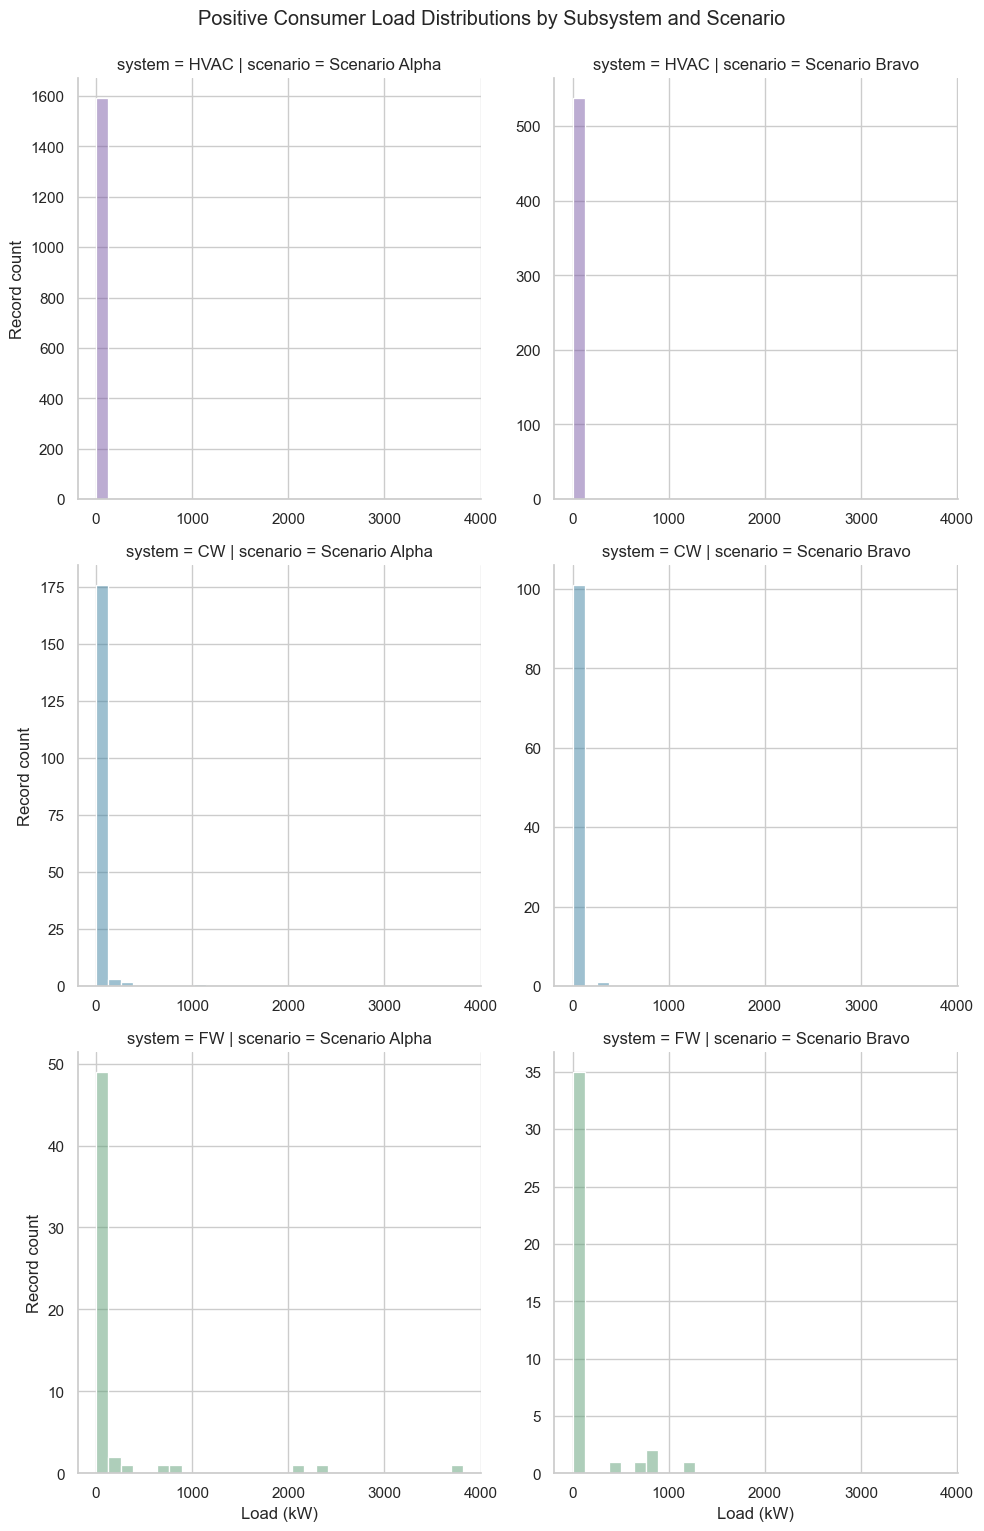

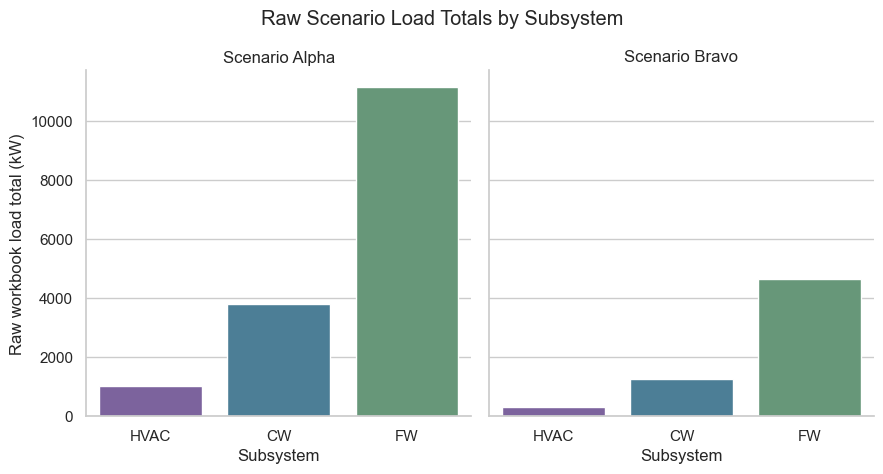

In [15]:
if plotting_available:
    sns.set_theme(style="whitegrid")

    # Plot positive load distributions by subsystem and scenario
    plot_data = cooling_records.melt(
        id_vars=["system"],
        value_vars=["alpha_load_model_kw", "bravo_load_model_kw"],
        var_name="scenario",
        value_name="load_kw"
    )

    plot_data["scenario"] = plot_data["scenario"].replace({
        "alpha_load_model_kw": "Scenario Alpha",
        "bravo_load_model_kw": "Scenario Bravo"
    })

    plot_data = plot_data[plot_data["load_kw"] > 0]

    graph = sns.displot(
        data=plot_data,
        x="load_kw",
        hue="system",
        row="system",
        col="scenario",
        row_order=SYSTEM_ORDER,
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        bins=30,
        facet_kws={"sharex": False, "sharey": False},
        legend=False,
    )
    graph.fig.suptitle("Positive Consumer Load Distributions by Subsystem and Scenario", y=1.02)
    graph.set_axis_labels("Load (kW)", "Record count")
    plt.savefig(figures_output_path / "eda_load_distributions.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Plot raw total loads by system and scenario
    totals_for_plot = load_summary.melt(
        id_vars=["system"],
        value_vars=["alpha_raw_sum_kw", "bravo_raw_sum_kw"],
        var_name="scenario",
        value_name="load_kw"
    )
    totals_for_plot["scenario"] = totals_for_plot["scenario"].replace({
        "alpha_raw_sum_kw": "Scenario Alpha",
        "bravo_raw_sum_kw": "Scenario Bravo"
    })

    graph = sns.catplot(
        data=totals_for_plot,
        x="system",
        y="load_kw",
        hue="system",
        col="scenario",
        order=SYSTEM_ORDER,
        hue_order=SYSTEM_ORDER,
        palette=SYSTEM_PALETTE,
        kind="bar",
        height=4.5,
        aspect=1.0,
        dodge=False,
        legend=False,
        sharey=True,
    )
    graph.fig.suptitle("Raw Scenario Load Totals by Subsystem", y=1.05)
    graph.set_axis_labels("Subsystem", "Raw workbook load total (kW)")
    graph.set_titles("{col_name}")
    graph.savefig(figures_output_path / "eda_system_load_totals.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Skipping plots because matplotlib and seaborn are not installed in this Python environment.")


## EDA notes and decisions for the next notebook

From this EDA I have identified the following points:

1. The workbook has one sheet called `data`.
2. The raw dataset contains 2,457 rows and 37 columns.
3. Blank numerical scenario fields are common, especially for subsystem columns where the row is not active. I will keep reporting these blanks, but convert them to zero for modelling.
4. The raw HVAC load totals match the expected deterministic checks very closely.
5. The CW and FW raw totals do not directly equal the expected deterministic cascade totals, which confirms that the cascade logic needs to be handled carefully.
6. `ITEM_001103` appears once in FW and is a clear CW-to-FW propagation candidate.
7. `ITEM_000955` appears twice in CW, so I need to resolve the exact exclusion rule before finalising the deterministic baseline.

The next notebook should calculate the deterministic baseline using the cascade equations and should explicitly test the propagation-row logic before comparing loads with capacity.